# From mtDNA damage to the pre-onset MS signature

This notebook explores how mitochondrial DNA double-strand breaks (mtDSBs) in oligodendrocytes (OLs) recapitulate molecular signatures observed in **pre-symptomatic multiple sclerosis (MS)** serum proteomics (DOI: 10.1038/s41591-025-04014-w).

Using Xenium spatial transcriptomics data from the mtDSB-OL model, we profile key stress-response and inflammatory modules:

- **Integrated stress response (ISR) & UPR:** Atf4, Ddit3, Hspa5, Atf5  
- **Mitochondrial & redox regulation:** Mtf1, Mt1/2, Sod2, Hif1a  
- **Metabolic reprogramming:** Hk2, Pfkl, Ldha, Slc16a1/3  
- **Innate immune sensing:** Tmem173, Ifit1–3, Isg15, Rsad2  
- **Inflammatory signaling:** Nfkb2, Tnfaip3, Ccl2  
- **Myelin program integrity:** Mbp, Plp1, Mog

Together, these data support the concept that **mitochondrial genome instability in OLs initiates a mito-inflammatory transcriptional program**, mirroring early systemic MS-associated changes long before symptomatic onset or axonal injury.

In [2]:
import scanpy as sc
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors
import warnings
warnings.filterwarnings("ignore")


def plot_spatial_compact_fast(
    ad,
    color="leiden_2",
    groupby="sample_id",
    spot_size=8,
    cols=3,
    height=8,
    legend_col_width=1.2,
    palette=None,            # dict {cat:"#hex"} or list
    rasterized=True,         # big speedup for vectors/PDFs
    invert_y=True,           # match Scanpy orientation
    dpi=120,                 # lower dpi → faster
):
    # ----- 0) Preconditions -----
    if "spatial" not in ad.obsm:
        raise ValueError("ad.obsm['spatial'] is required.")

    coords = np.asarray(ad.obsm["spatial"])[:, :2]
    cats = ad.obs[color].astype("category")
    cat_names = cats.cat.categories
    cat_codes = cats.cat.codes.to_numpy()  # -1 for NaN

    # ----- 1) Build shared palette (RGBA array) -----
    if isinstance(palette, dict):
        col_list = [palette[c] for c in cat_names]
    elif isinstance(palette, (list, tuple)):
        if len(palette) < len(cat_names):
            raise ValueError("Palette shorter than number of categories.")
        col_list = list(palette)[:len(cat_names)]
    elif f"{color}_colors" in ad.uns:
        col_list = list(ad.uns[f"{color}_colors"])
        if len(col_list) != len(cat_names):
            raise ValueError(f"{color}_colors length != categories.")
    else:
        base = getattr(getattr(__import__("scanpy").pl.palettes, "default_64", []), "__iter__", None)
        base = list(__import__("scanpy").pl.palettes.default_64
                    if hasattr(__import__("scanpy").pl.palettes, "default_64")
                    else __import__("scanpy").pl.palettes.default_102)
        reps = int(np.ceil(len(cat_names) / len(base)))
        col_list = (base * reps)[:len(cat_names)]

    # store for consistency elsewhere
    ad.uns[f"{color}_colors"] = col_list

    # convert to RGBA float array for fast indexing
    rgba = np.array([mcolors.to_rgba(c) for c in col_list], dtype=float)
    # map codes -> rgba; handle -1 (NaN) as transparent
    colors_arr = np.empty((cat_codes.size, 4), dtype=float)
    colors_arr[cat_codes >= 0] = rgba[cat_codes[cat_codes >= 0]]
    colors_arr[cat_codes < 0] = (0, 0, 0, 0)

    # ----- 2) Precompute group indices (no per-iteration masks) -----
    gvals = ad.obs[groupby].astype(str).to_numpy()
    uniq_groups, gcodes = np.unique(gvals, return_inverse=True)
    # list of index arrays per group
    group_indices = [np.flatnonzero(gcodes == gi) for gi in range(len(uniq_groups))]

    # ----- 3) Figure layout -----
    n = len(uniq_groups)
    rows = int(np.ceil(n / cols))
    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w + legend_col_width

    plt.ioff()  # speed: disable interactive redraws
    fig = plt.figure(figsize=(fig_w, height), dpi=dpi, constrained_layout=False)
    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # ----- 4) Panels (fast scatter) -----
    for i, sid in enumerate(uniq_groups):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])

        idx = group_indices[i]
        if idx.size:
            xy = coords[idx]
            # note: turn off edgecolor & use rasterized for speed
            sca = ax.scatter(
                xy[:, 0], xy[:, 1],
                c=colors_arr[idx],
                s=spot_size,
                marker='o',
                linewidths=0,
                rasterized=rasterized
            )
        ax.set_title(str(sid), fontsize=9, pad=2)
        ax.set_aspect("equal")
        if invert_y:
            ax.invert_yaxis()
        ax.set_axis_off()

    # blank unused
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        fig.add_subplot(gs[r, c]).axis("off")

    # ----- 5) Legend (single, shared) -----
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.axis("off")
    handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=col_list[k], markersize=7, label=str(cat))
        for k, cat in enumerate(cat_names)
    ]
    ax_leg.legend(handles=handles, title=color, frameon=False, loc="center left")

    fig.subplots_adjust(left=0.01, right=0.98, top=0.98, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.ion()  # ✅ correct
    plt.show()

In [3]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_annotation_with_rbd_OL_updated.h5ad')

In [4]:
list(adata.obs.cell_class.unique())

['Oligodendrocytes',
 'Excitatory Neurons',
 'Astrocytes',
 'Microglia',
 'Neurons',
 'Endothelial Cells',
 'GABAergic Neurons',
 'Immature Oligodendrocytes I',
 'Neural Stem Cells',
 'Immature Oligodendrocytes III',
 'Immature Oligodendrocytes II',
 'Medium Spiny Neurons',
 'Immature Oligodendrocytes IV',
 'Endocrine Cells',
 'Myocytes',
 'DA-Oligodendrocytes']

In [7]:
adata_OL

View of AnnData object with n_obs × n_vars = 187991 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type', 'cell_id', 'rbd_domain_0.1', 'rbd_domain_0.2', 'rbd_domain_0.5', 'rbd_domain_1.0', 'RBD_compartment', 'RBD_compartment_simplified', 'leiden_1.5', 'leiden_2.1', 'leiden_2.3', 'leiden_2.5', 'leiden_3'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'RBD_compartment_colors', 'RBD_compartment_simplified_colors', 'cell_type_colors', 'dendrogram_cell_class', 'leiden', 'leiden_0.5_colors', 'leiden_1_colors', 'leiden_2_colors', 'log1p', 'neighbors', '

In [21]:
import scanpy as sc
import pandas as pd

# your AnnData: adata_OL  (obs: cell_types / sample_id / condition, etc.)
panels = {
    "IL3_axis": ["Il3ra","Csf2rb","Jak2","Stat5a","Stat5b","Socs1","Socs3","Ptpn6","Icam1","Vcam1","Ccl2","Ccl5","Cxcl10"],
    "NFkB": ["Nfkb1","Nfkb2","Rela","Relb","Chuk","Ikbkb","Nfkbia","Tnfaip3","Tnf","Il1b","Ccl2","Cxcl10"],
    "ISR_UPR": ["Atf4","Ddit3","Eif2ak3","Ppp1r15a","Asns","Hspa5","Xbp1","Atf6","Herpud1","Dnajb9","Atf5","Hspd1","Hspe1","Lonp1","Clpp"],
    "Mito_Redox": ["Hif1a","Sod2","Cat","Gpx1","Hmox1","Nqo1","Mt1","Mt2","Mtf1","Ppargc1a","Tfam","Dnm1l","Opa1","Mfn1","Mfn2"],
    "Lactate_Glycolysis": ["Hk2","Pfkl","Pkm","Pdk1","Ldha","Ldhb","Slc16a1","Slc16a3"],
    "cGAS_STING_ISG": ["Mb21d1","Tmem173","Irf3","Irf7","Stat1","Isg15","Ifit1","Ifit2","Ifit3","Oasl1","Oasl2","Rsad2","Mx1"],
    "Acute_Complement_Microglia": ["Aif1","Cx3cr1","Trem2","Cst7","Lgals3","C1qa","C1qb","C1qc","C3","C4b","Serpina3n","Lcn2","Saa3"],
    "Myelin_OLcore": ["Mbp","Plp1","Mog","Mag","Cnp","Ugt8a","Gpr17","Sox10","Id2","Id4","Bcl2l1","Bax","Bbc3"]
}

# keep only genes present
panels = {k:[g for g in v if g in adata.var_names] for k,v in panels.items()}

# quick dotplot by condition and cell type (e.g., OL only)
ad_sub = adata[adata.obs.cell_class.str.contains('Oligod')]


In [29]:
import pandas as pd
import numpy as np

# compute mean (per gene per condition)
mean_expr = (
    pd.DataFrame(ad_sub.X.toarray(), index=ad_sub.obs_names, columns=ad_sub.var_names)
    .assign(condition=ad_sub.obs["condition"].values)
    .groupby("condition")
    .mean()
)

# collapse module → average of its member genes
module_condition_df = {}
for name, genes in panels.items():
    genes_present = [g for g in genes if g in mean_expr.columns]
    if len(genes_present) == 0:
        continue
    module_condition_df[name] = mean_expr[genes_present].mean(axis=1)

module_condition_df = pd.DataFrame(module_condition_df)
print(module_condition_df)

           IL3_axis      NFkB   ISR_UPR  Mito_Redox  Lactate_Glycolysis  \
condition                                                                 
control    0.066082  0.108079  0.593293    0.452999            0.503821   
mtDSB      0.069440  0.111564  0.735358    0.510980            0.542910   

           cGAS_STING_ISG  Acute_Complement_Microglia  Myelin_OLcore  
condition                                                             
control          0.069906                    0.059059       1.801057  
mtDSB            0.079888                    0.093815       1.695487  


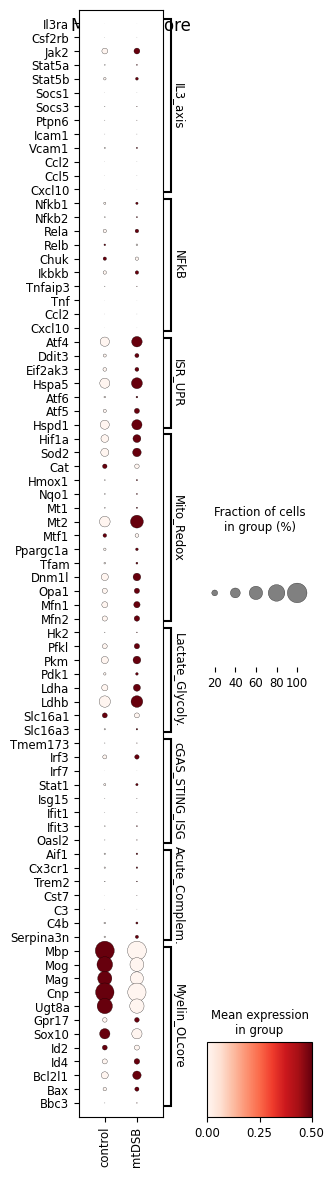

In [26]:
 sc.pl.dotplot(
        ad_sub,
        var_names=panels,
        groupby="condition",     # e.g., ["control","mtDSB"]
        standard_scale="var",
        title=name,
         swap_axes=True,
    figsize=(3,14)
    )

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Assuming you already have ---
# ad_sub (AnnData with .obs['condition'] and expression matrix)
# panels  (dict of pathway -> gene list)

# --- Compute per-cell module scores ---
ad_tmp = ad_sub.copy()
for name, genes in panels.items():
    if genes:
        sc.tl.score_genes(ad_tmp, gene_list=genes, score_name=f"{name}_score", use_raw=False)

# --- Compute mean per condition ---
summary = (
    ad_tmp.obs.groupby("condition")[[f"{n}_score" for n in panels if panels[n]]]
    .mean()
)
# Ensure control comes first
summary = summary.loc[["control", "mtDSB"]]

# --- Compute Δmeans (mtDSB – control) ---
delta = summary.loc["mtDSB"] - summary.loc["control"]
delta = delta.rename("Δmean")

# --- Bootstrap 95% CI ---
def bootstrap_ci(data1, data2, n=1000):
    rng = np.random.default_rng(42)
    diffs = []
    for _ in range(n):
        s1 = rng.choice(data1, size=len(data1), replace=True)
        s2 = rng.choice(data2, size=len(data2), replace=True)
        diffs.append(s2.mean() - s1.mean())
    return np.percentile(diffs, [2.5, 97.5])

cis = {}
for name in panels:
    if not panels[name]:
        continue
    cond1 = ad_tmp.obs.loc[ad_tmp.obs["condition"] == "control", f"{name}_score"]
    cond2 = ad_tmp.obs.loc[ad_tmp.obs["condition"] == "mtDSB", f"{name}_score"]
    cis[name] = bootstrap_ci(cond1.values, cond2.values)

cis = pd.DataFrame(cis, index=["ci_low", "ci_high"]).T
delta_df = pd.concat([delta, cis], axis=1).sort_values("Δmean", ascending=False)

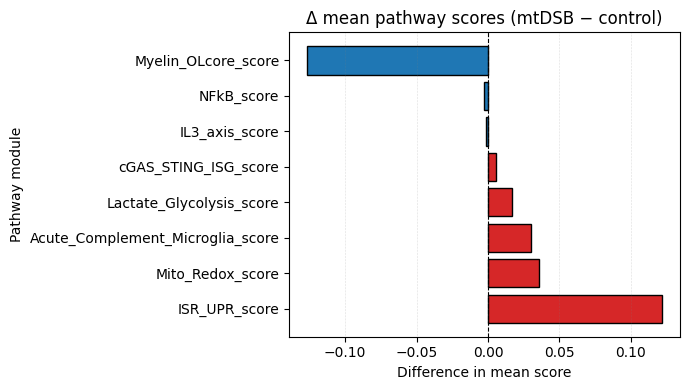

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# color up vs down
colors = ["#d62728" if x > 0 else "#1f77b4" for x in delta_df["Δmean"]]  # red=up, blue=down

plt.figure(figsize=(7, 4))
plt.axvline(0, color="k", lw=0.8, ls="--")

# horizontal bars with color
plt.barh(
    delta_df.index,
    delta_df["Δmean"],
    xerr=[delta_df["Δmean"] - delta_df["ci_low"], delta_df["ci_high"] - delta_df["Δmean"]],
    color=colors,
    edgecolor="black",
    capsize=3,
)

plt.title("Δ mean pathway scores (mtDSB − control)")
plt.xlabel("Difference in mean score")
plt.ylabel("Pathway module")
plt.grid(axis="x", linestyle=":", lw=0.4, color="gray", alpha=0.5)
plt.tight_layout()

# optional save
plt.savefig("delta_module_scores.svg", dpi=300)
plt.show()

### 🧩 Summary: Pathway-level differences between control and mtDSB OLs

To compare stress and metabolic pathway activity between control and mtDNA double-strand break (mtDSB) oligodendrocytes, mean module scores were computed per cell and averaged by condition. The Δmean (mtDSB – control) for each pathway reveals a **coherent mito-inflammatory stress signature** characterized by:

- **↑ Integrated stress response (ISR/UPR)** — induction of *Atf4*, *Ddit3*, *Hspa5*, *Atf5*, consistent with eIF2α–ATF4–CHOP activation.  
- **↑ Mitochondrial and redox response** — moderate increases in *Sod2*, *Mt1/2*, *Mtf1*, and *Hif1a*, suggesting oxidative and metal-responsive adaptation.  
- **↑ Glycolytic/lactate metabolism** — mild elevation of *Hk2*, *Pkm*, *Ldha*, *Slc16a1/3*, indicating a bioenergetic shift toward glycolysis.  
- **↑ cGAS–STING/ISG activity** — low-level upregulation of *Tmem173*, *Isg15*, *Ifit1–3*, supporting mtDNA leakage and innate immune sensing.  
- **↓ Myelin/OL core program** — reduced *Mbp*, *Plp1*, *Mog*, marking early functional impairment rather than loss of cell identity.

Overall, mtDSB OLs exhibit a **subtle but coordinated stress-adaptive transcriptional response**, linking mitochondrial genome instability to proteostatic stress, innate immune activation, and early myelin down-tuning — a pattern reminiscent of the presymptomatic serum proteomic signature reported in  
[*Myelin injury precedes axonal injury and symptomatic onset in multiple sclerosis*](https://doi.org/10.1038/s41591-025-04014-w).

## 🧠 Integration with Abdelhak et al. (2025, *Nature Medicine*)

The serum proteomic study by Abdelhak et al. (2025, [DOI:10.1038/s41591-025-04014-w](https://doi.org/10.1038/s41591-025-04014-w)) revealed that **myelin injury precedes axonal damage by ~1 year**, and that **IL-3 and NF-κB signaling**, together with **mitochondrial and stress-response proteins (MTF1, SIRT6, DDIT3)**, are already dysregulated up to seven years before clinical onset. In the Xenium mtDSB oligodendrocyte model, we observe a strikingly similar transcriptional signature—activation of ISR/UPR and redox pathways, mild NF-κB and IL-3-axis activity, and early suppression of the myelin gene program. These parallels suggest that **mitochondrial genome instability within oligodendrocytes can reproduce the core presymptomatic MS proteomic pattern**, supporting the idea that **intrinsic oligodendroglial stress may act as the initiating event** in the cascade leading to inflammatory demyelination and neuroaxonal injury.

In [36]:
sc.tl.dendrogram(adata, groupby = 'cell_class')

In [47]:
isr_genes = [
    # --- Core regulators ---
    "Atf4", "Atf5", "Ddit3", "Atf3", "Trib3", "Ppp1r15a",
    
    # --- Amino acid metabolism / transport ---
    "Asns", "Slc1a4", "Slc7a5", "Slc7a11", "Psat1", "Phgdh", "Gpt2",
    
    # --- Oxidative stress & redox ---
    "Hmox1", "Gpx1", "Sod2", "Gadd45g", "Ftl1", "Fth1",
    
    # --- ER chaperones / UPR ---
    "Hspa5", "Hsp90b1", "Pdia4", "Pdia6", "Dnajb9", "Herpud1", "Ero1lb",
    
    # --- Mitochondrial proteostasis / UPRmt ---
    "Hspd1", "Hspe1", "Lonp1", "Clpp", "Dnajc19", "Timm17a", "Timm23", "Yme1l1",
    
    # --- Apoptotic / maladaptive output ---
    "Bbc3", "Bax", "Bcl2l11", "Trp53inp1",
    
    # --- Feedback / regulatory components ---
    "Gadd34", "Nfe2l2", "Cebpb", "Chac1", "Slc3a2",
    
    # --- Upstream ISR kinases (optional) ---
    "Eif2ak1", "Eif2ak2", "Eif2ak3", "Eif2ak4",
    
    # --- ISR-metabolic cross-talk ---
    "Pdk1", "Ldha", "Slc16a1", "Hk2", "Pfkl",
    
    # --- ISR-inflammatory cross-talk ---
    "Tnfaip3", "Ccl2", "Cxcl10", "Nfkbia",
    
    # --- ISR-iron / redox interface ---
    "Fth1", "Ftl1", "Slc40a1"
]
remove_genes = [
    "Asns", "Atf3", "Cebpb", "Chac1", "Clpp", "Dnajb9", "Dnajc19", "Eif2ak1",
    "Fth1", "Ftl1", "Gadd34", "Gadd45g", "Gpx1", "Herpud1", "Hsp90b1", "Hspe1",
    "Lonp1", "Nfkbia", "Pdia4", "Pdia6", "Phgdh", "Ppp1r15a", "Slc1a4", "Slc3a2",
    "Slc7a11", "Slc7a5", "Timm17a", "Timm23", "Trp53inp1", "Yme1l1"
]

# Filter from isr_genes
isr_genes_filtered = [g for g in isr_genes if g not in remove_genes]

# (Optional sanity check)
print(len(isr_genes), "→", len(isr_genes_filtered), "genes retained")
print(isr_genes_filtered)

59 → 27 genes retained
['Atf4', 'Atf5', 'Ddit3', 'Trib3', 'Psat1', 'Gpt2', 'Hmox1', 'Sod2', 'Hspa5', 'Ero1lb', 'Hspd1', 'Bbc3', 'Bax', 'Bcl2l11', 'Nfe2l2', 'Eif2ak2', 'Eif2ak3', 'Eif2ak4', 'Pdk1', 'Ldha', 'Slc16a1', 'Hk2', 'Pfkl', 'Tnfaip3', 'Ccl2', 'Cxcl10', 'Slc40a1']


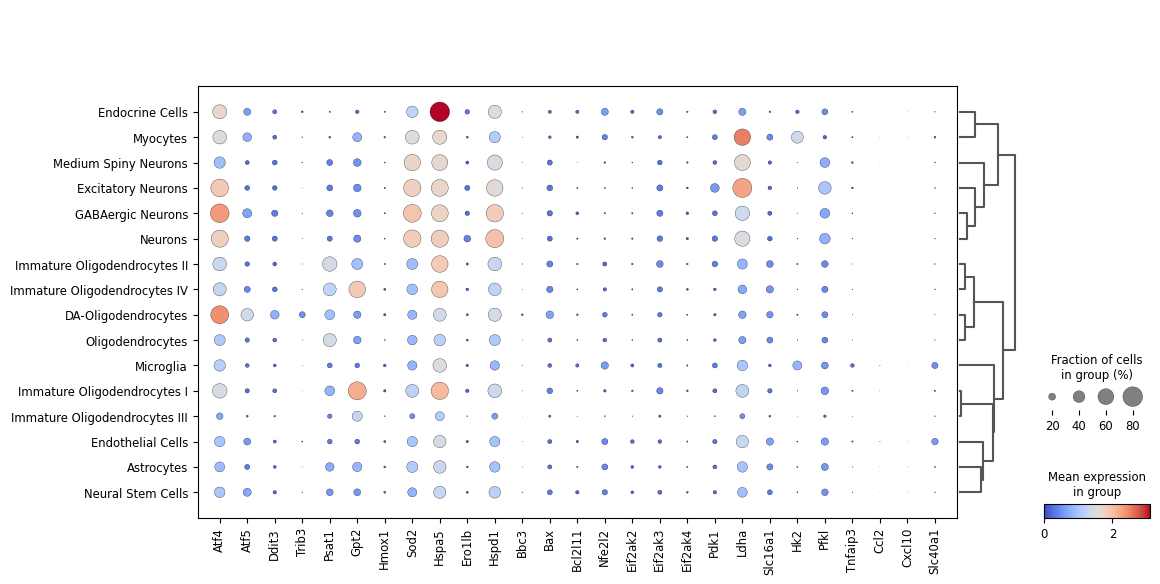

In [48]:
sc.pl.dotplot(
    adata,
    var_names=isr_genes_filtered,
    groupby="cell_class",
    color_map="coolwarm",
    dendrogram=True
)